In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ustawienie estetyki wykresów

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

# 2. Ładowanie danych syntetycznych

In [16]:
try:
    # Ścieżka bez kropek na początku - idzie w dół od głównego folderu repozytorium
    df_mes = pd.read_csv('mes_production_logs.csv')
    print(f"Pomyślnie załadowano {len(df_mes)} rekordów z systemu MES.\n")
except FileNotFoundError:
    try:
        # Alternatywa: Jeśli środowisko jednak patrzy lokalnie z folderu notebooks
        df_mes = pd.read_csv('mes_production_logs.csv')
        print(f"Pomyślnie załadowano {len(df_mes)} rekordów z systemu MES (ścieżka względna).\n")
    except FileNotFoundError:
        print("Błąd: Nie można zlokalizować pliku. Sprawdź, z jakiego poziomu uruchamiasz skrypt.")

Pomyślnie załadowano 1000 rekordów z systemu MES.



# 3. Kalkulacja opóźnienia i filtrowanie rekordów (actual > planned)

In [17]:
df_mes['delay_min'] = df_mes['actual_duration_min'] - df_mes['planned_duration_min']
df_delayed = df_mes[df_mes['delay_min'] > 0].copy()

# 4. Agregacja danych

In [18]:
df_pivot = df_delayed.pivot_table(
    index='workcenter', 
    columns='status', 
    values='delay_min', 
    aggfunc='sum'
).fillna(0)

df_pivot['total_delay'] = df_pivot.sum(axis=1)
df_pivot = df_pivot.sort_values(by='total_delay', ascending=False).drop(columns='total_delay')

# 5. Tworzenie Wykresu Słupkowego Skumulowanego

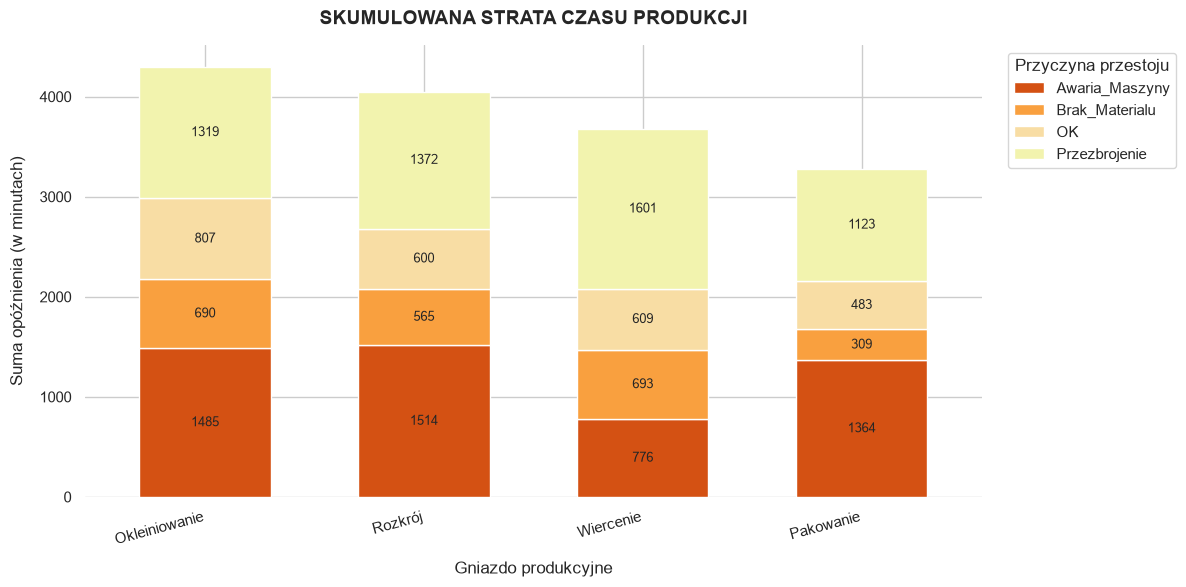

In [25]:
import os

fig, ax = plt.subplots()
colors = ['#d45113', '#f9a03f', '#f8dda4', '#f2f3ae']
df_pivot.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors[:len(df_pivot.columns)], 
    edgecolor='white',
    width=0.6
)
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%.0f', fontsize=9)

plt.title('SKUMULOWANA STRATA CZASU PRODUKCJI', fontsize=14, pad=15, weight='bold')
plt.xlabel('Gniazdo produkcyjne', fontsize=12, labelpad=10)
plt.ylabel('Suma opóźnienia (w minutach)', fontsize=12, labelpad=10)

plt.xticks(rotation=15, ha='right')

plt.legend(
    title='Przyczyna przestoju', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=True, 
    facecolor='white'
)

sns.despine(left=True, bottom=True)
plt.tight_layout()

# Utwórz folder jeśli nie istnieje
os.makedirs('../reports/figures/', exist_ok=True)
plt.savefig('../reports/figures/analiza_skumulowanych_opoznien_mes_stackedbar.png', dpi=300)
plt.show()